In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import cv2
from collections import Counter

# Image processing and augmentation
from PIL import Image
import torchvision.transforms as transforms

# PyTorch libraries for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models

# Scikit-learn for splitting data and evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Other utilities
import warnings
warnings.filterwarnings("ignore")


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import json


In [4]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [5]:
!unzip -q /content/drive/MyDrive/archive.zip -d /content/drive/MyDrive/


unzip:  cannot find or open /content/drive/MyDrive/archive.zip, /content/drive/MyDrive/archive.zip.zip or /content/drive/MyDrive/archive.zip.ZIP.


In [6]:
base_data_path = "/content/drive/MyDrive/DATASETS/BUSI_DATASET"


In [7]:
masks = glob.glob(os.path.join(base_data_path, "*/*_mask.png"))
# Replace '_mask' to get the actual image paths
images = [mask_path.replace("_mask", "") for mask_path in masks]

# Create labels based on the folder name in the image path
# Benign: 0, Normal: 1, Malignant: 2
labels = []
for image_path in images:
    if 'benign' in image_path:
        labels.append(0)
    elif 'normal' in image_path:
        labels.append(1)
    elif 'malignant' in image_path:
        labels.append(2)

# Create a DataFrame to manage the dataset
dataset_df = pd.DataFrame({'image_path': images, 'labels': labels})
print("Original Dataset Head:")
print(dataset_df.head())

Original Dataset Head:
                                          image_path  labels
0  /content/drive/MyDrive/DATASETS/BUSI_DATASET/b...       0
1  /content/drive/MyDrive/DATASETS/BUSI_DATASET/b...       0
2  /content/drive/MyDrive/DATASETS/BUSI_DATASET/b...       0
3  /content/drive/MyDrive/DATASETS/BUSI_DATASET/b...       0
4  /content/drive/MyDrive/DATASETS/BUSI_DATASET/b...       0


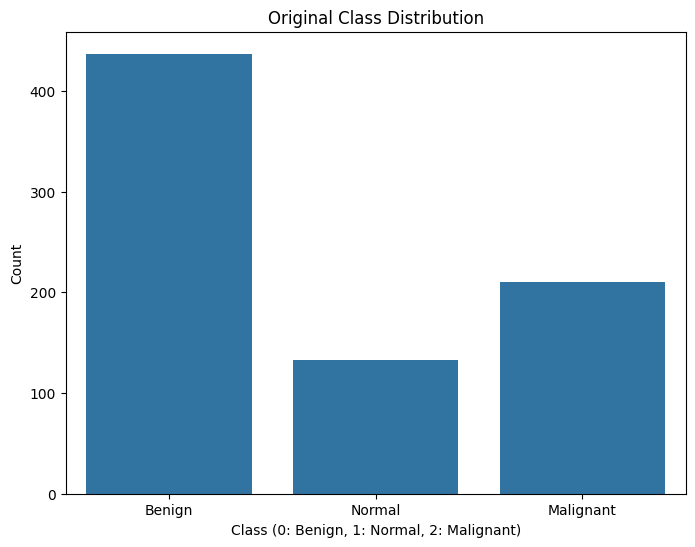

In [8]:

plt.figure(figsize=(8, 6))
sns.countplot(x='labels', data=dataset_df)
plt.title('Original Class Distribution')
plt.xlabel('Class (0: Benign, 1: Normal, 2: Malignant)')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Benign', 'Normal', 'Malignant'])
plt.show()

In [9]:
# Define GAN parameters
nz = 100  # Size of the latent z vector (i.e., size of generator input)
ngf = 64  # Size of feature maps in generator
ndf = 64  # Size of feature maps in discriminator
nc = 3    # Number of channels in the training images (RGB)

# Generator Network
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# Discriminator Network
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input)

# Custom Dataset class for GAN and main model
class CustomImageMaskDataset(Dataset):
    def __init__(self, dataframe, image_transform=None):
        self.data = dataframe
        self.image_transform = image_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image_path = self.data.iloc[idx]['image_path']
        label = self.data.iloc[idx]['labels']

        image = Image.open(image_path).convert('RGB')

        if self.image_transform:
            image = self.image_transform(image)

        return image, label


In [10]:
# **3.2. Train the GAN**
#@markdown This process can be time-consuming. For a project presentation, you can show this code and the final generated images without running this cell live.

# Filter for malignant images only
gan_df = dataset_df[dataset_df['labels'] == 2]

# GAN-specific transforms and dataloader
gan_transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

gan_dataset = CustomImageMaskDataset(gan_df, gan_transform)
gan_dataloader = DataLoader(gan_dataset, batch_size=16, shuffle=True)


In [11]:
# Instantiate models
netG = Generator().to(device)
netD = Discriminator().to(device)

# Setup optimizer and loss
criterion = nn.BCELoss()
optimizerD = optim.Adam(netD.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [12]:
print("Starting GAN Training... (This may take a while, ~100 epochs recommended for good results)")
# Training Loop (shortened for demonstration)
num_epochs_gan = 500 # When deploying we have to run this for 500+ epochs
for epoch in range(num_epochs_gan):
    for i, data in enumerate(gan_dataloader, 0):
        # (1) Update Discriminator
        netD.zero_grad()
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), 1., dtype=torch.float, device=device)
        output = netD(real_cpu).view(-1)
        errD_real = criterion(output, label)
        errD_real.backward()

        noise = torch.randn(b_size, nz, 1, 1, device=device)
        fake = netG(noise)
        label.fill_(0.)
        output = netD(fake.detach()).view(-1)
        errD_fake = criterion(output, label)
        errD_fake.backward()
        errD = errD_real + errD_fake
        optimizerD.step()

        # (2) Update Generator
        netG.zero_grad()
        label.fill_(1.)
        output = netD(fake).view(-1)
        errG = criterion(output, label)
        errG.backward()
        optimizerG.step()

    if (epoch + 1) % 20 == 0:
        print(f'GAN Epoch [{epoch+1}/{num_epochs_gan}] Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f}')

print("Finished GAN Training.")

Starting GAN Training... (This may take a while, ~100 epochs recommended for good results)
GAN Epoch [20/500] Loss_D: 1.4731 Loss_G: 4.5690
GAN Epoch [40/500] Loss_D: 0.6909 Loss_G: 1.5874
GAN Epoch [60/500] Loss_D: 0.4140 Loss_G: 7.6759
GAN Epoch [80/500] Loss_D: 0.4580 Loss_G: 3.7121
GAN Epoch [100/500] Loss_D: 0.1033 Loss_G: 6.7028
GAN Epoch [120/500] Loss_D: 0.4429 Loss_G: 4.2333
GAN Epoch [140/500] Loss_D: 0.1724 Loss_G: 3.9193
GAN Epoch [160/500] Loss_D: 0.0220 Loss_G: 5.9822
GAN Epoch [180/500] Loss_D: 0.1034 Loss_G: 7.0911
GAN Epoch [200/500] Loss_D: 0.0435 Loss_G: 6.5840
GAN Epoch [220/500] Loss_D: 0.0060 Loss_G: 6.2466
GAN Epoch [240/500] Loss_D: 0.0098 Loss_G: 6.2030
GAN Epoch [260/500] Loss_D: 0.0098 Loss_G: 8.6040
GAN Epoch [280/500] Loss_D: 0.1210 Loss_G: 7.1026
GAN Epoch [300/500] Loss_D: 0.0060 Loss_G: 6.1269
GAN Epoch [320/500] Loss_D: 0.0440 Loss_G: 6.3472
GAN Epoch [340/500] Loss_D: 0.0890 Loss_G: 11.3205
GAN Epoch [360/500] Loss_D: 0.8256 Loss_G: 1.6664
GAN Epoch [3

In [13]:
 print("Generating synthetic images to balance classes...")
gan_aug_path = '/content/drive/MyDrive/DATASETS/BUSI_DATASET'
if not os.path.exists(gan_aug_path):
    os.makedirs(gan_aug_path)

Generating synthetic images to balance classes...


In [14]:
# Calculate how many images to generate for each minority class
label_counts = dataset_df['labels'].value_counts()
target_count = label_counts[0] # Target count is the count of the majority class (Benign)
new_paths = []
new_labels = []

In [15]:
  # Generate for Malignant class (label 2)
  num_to_generate_mal = target_count - label_counts[2]
  netG.eval()
  with torch.no_grad():
      for i in range(num_to_generate_mal):
          noise = torch.randn(1, nz, 1, 1, device=device)
          fake_image = netG(noise).detach().cpu()
          fake_image = (fake_image * 0.5) + 0.5 # De-normalize from Tanh
          img_array = fake_image.squeeze(0).permute(1, 2, 0).numpy() * 255
          img_array = img_array.astype(np.uint8)

          save_path = os.path.join(gan_aug_path, f'gan_malignant_{i}.png')
          Image.fromarray(img_array).save(save_path)
          new_paths.append(save_path)
          new_labels.append(2)

In [16]:
# For the 'normal' class, we will use traditional augmentation to balance
# This demonstrates a hybrid approach.
num_to_generate_nor = target_count - label_counts[1]
normal_paths = dataset_df[dataset_df['labels'] == 1]['image_path'].values
for i in range(num_to_generate_nor):
    img_path = random.choice(normal_paths)
    image = Image.open(img_path)
    aug_image = transforms.RandomHorizontalFlip(p=1.0)(image) # Simple but effective for this class

    save_path = os.path.join(gan_aug_path, f'aug_normal_{i}.png')
    aug_image.save(save_path)
    new_paths.append(save_path)
    new_labels.append(1)


Synthetic data generation complete.

New Balanced Class Distribution:


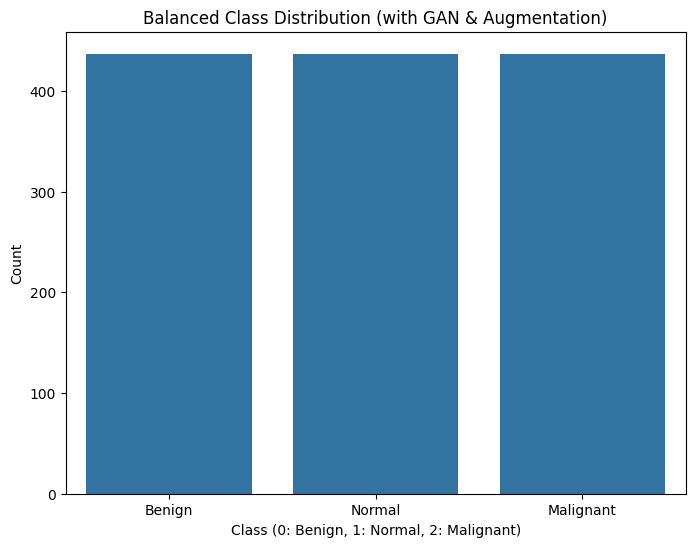

In [17]:
 # Create a dataframe for the new images and concatenate
new_data_df = pd.DataFrame({'image_path': new_paths, 'labels': new_labels})
balanced_df = pd.concat([dataset_df, new_data_df], ignore_index=True)

print("Synthetic data generation complete.")
print("\nNew Balanced Class Distribution:")
plt.figure(figsize=(8, 6))
sns.countplot(x='labels', data=balanced_df)
plt.title('Balanced Class Distribution (with GAN & Augmentation)')
plt.xlabel('Class (0: Benign, 1: Normal, 2: Malignant)')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Benign', 'Normal', 'Malignant'])
plt.show()

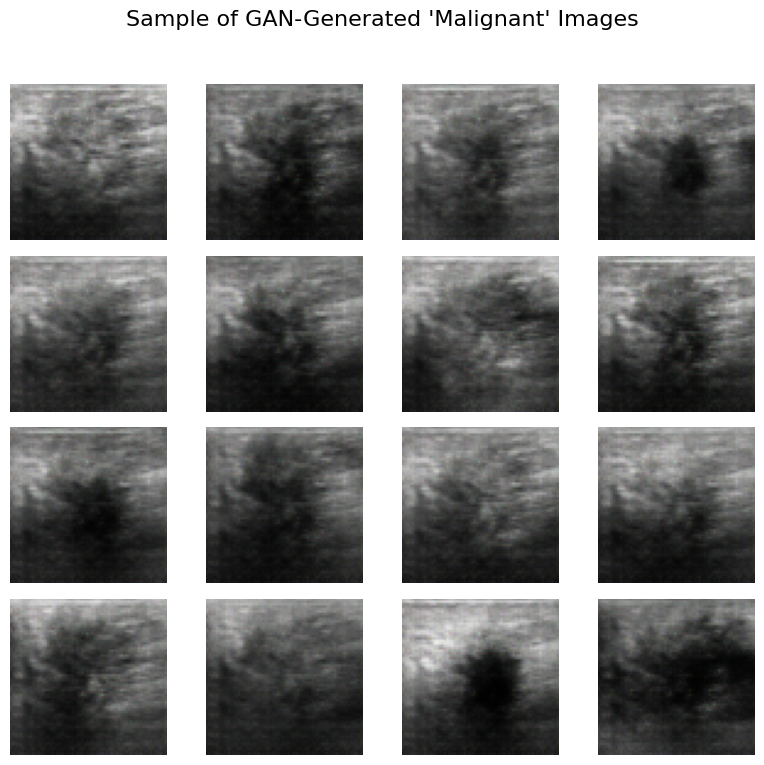

In [18]:
### **3.4. Visualize Generated Images**
# Plot some of the generated images
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
gan_files = glob.glob(f'{gan_aug_path}/gan_malignant_*.png')[:16]

for i, ax in enumerate(axes.flat):
    if i < len(gan_files):
        img = Image.open(gan_files[i])
        ax.imshow(img)
        ax.axis('off')

plt.suptitle("Sample of GAN-Generated 'Malignant' Images", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [19]:
# Split the balanced dataset
train_df, test_df = train_test_split(balanced_df, test_size=0.3, stratify=balanced_df['labels'], random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, stratify=test_df['labels'], random_state=42)

# Define more comprehensive on-the-fly transforms
image_size = 224 # Standard size for many pretrained models

train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create custom datasets
train_dataset = CustomImageMaskDataset(train_df, train_transforms)
val_dataset = CustomImageMaskDataset(val_df, val_test_transforms)
test_dataset = CustomImageMaskDataset(test_df, val_test_transforms)

In [20]:
# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [21]:
# **4.2. Define the Trainer Class**
class Trainer:
    def __init__(self, model, optimizer, criterion, scheduler=None, device='cuda'):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.scheduler = scheduler
        self.metrics = {'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}
        self.scaler = GradScaler()
        self.best_val_accuracy = 0.0
        self.best_model_path = '/content/drive/MyDrive/model_for_plots.pth'

    def train_epoch(self, train_loader):
        self.model.train()
        total_loss, correct_predictions = 0.0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            with autocast():
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
            self.scaler.scale(loss).backward()
            self.scaler.step(self.optimizer)
            self.scaler.update()
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
        epoch_loss = total_loss / len(train_loader)
        epoch_accuracy = correct_predictions / len(train_loader.dataset)
        return epoch_loss, epoch_accuracy

    def evaluate(self, val_loader):
        self.model.eval()
        total_loss, correct_predictions = 0.0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                total_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                correct_predictions += (predicted == labels).sum().item()
        epoch_loss = total_loss / len(val_loader)
        epoch_accuracy = correct_predictions / len(val_loader.dataset)
        return epoch_loss, epoch_accuracy

    def train(self, train_loader, val_loader, num_epochs=50):
        for epoch in range(num_epochs):
            train_loss, train_accuracy = self.train_epoch(train_loader)
            val_loss, val_accuracy = self.evaluate(val_loader)
            print(f'Epoch {epoch + 1}/{num_epochs} => '
                  f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f} | '
                  f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}')
            self.metrics['train_loss'].append(train_loss)
            self.metrics['train_accuracy'].append(train_accuracy)
            self.metrics['val_loss'].append(val_loss)
            self.metrics['val_accuracy'].append(val_accuracy)

            if val_accuracy > self.best_val_accuracy:
                self.best_val_accuracy = val_accuracy

                # Save the best model's weights
                torch.save(self.model.state_dict(), self.best_model_path)

                # --- ADD THIS: Save the metrics dictionary to a JSON file ---
                metrics_path = '/content/drive/MyDrive/training_metrics.json'
                with open(metrics_path, 'w') as f:
                    json.dump(self.metrics, f)

                print(f"   -> New best model and metrics saved with accuracy: {self.best_val_accuracy:.4f}")

            if self.scheduler:
                self.scheduler.step(val_accuracy)

In [22]:
# Load pretrained EfficientNet-B7
model_effnet = models.efficientnet_b7(pretrained=True)

Downloading: "https://download.pytorch.org/models/efficientnet_b7_lukemelas-c5b4e57e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b7_lukemelas-c5b4e57e.pth


100%|██████████| 255M/255M [00:01<00:00, 167MB/s]


In [23]:
# Freeze all model parameters initially
for param in model_effnet.parameters():
    param.requires_grad = False

In [24]:
# Unfreeze the final classifier layers and modify for 3 classes
num_ftrs = model_effnet.classifier[1].in_features
model_effnet.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 3)
)

In [25]:
model_effnet = model_effnet.to(device)


In [26]:
from torch.cuda.amp import autocast, GradScaler # This was the missing import


Epoch 1/80 => Train Loss: 0.8795, Train Acc: 0.6543 | Val Loss: 0.8888, Val Acc: 0.6193
   -> New best model and metrics saved with accuracy: 0.6193
Epoch 2/80 => Train Loss: 0.7122, Train Acc: 0.7535 | Val Loss: 0.8153, Val Acc: 0.7107
   -> New best model and metrics saved with accuracy: 0.7107
Epoch 3/80 => Train Loss: 0.6908, Train Acc: 0.7666 | Val Loss: 0.7351, Val Acc: 0.7766
   -> New best model and metrics saved with accuracy: 0.7766
Epoch 4/80 => Train Loss: 0.6824, Train Acc: 0.7874 | Val Loss: 0.7014, Val Acc: 0.7766
Epoch 5/80 => Train Loss: 0.6578, Train Acc: 0.7939 | Val Loss: 0.7171, Val Acc: 0.7563
Epoch 6/80 => Train Loss: 0.6507, Train Acc: 0.7928 | Val Loss: 0.7300, Val Acc: 0.7360
Epoch 7/80 => Train Loss: 0.6458, Train Acc: 0.7972 | Val Loss: 0.7081, Val Acc: 0.7766
Epoch 8/80 => Train Loss: 0.6075, Train Acc: 0.8190 | Val Loss: 0.7154, Val Acc: 0.7817
   -> New best model and metrics saved with accuracy: 0.7817
Epoch 9/80 => Train Loss: 0.6009, Train Acc: 0.8222 

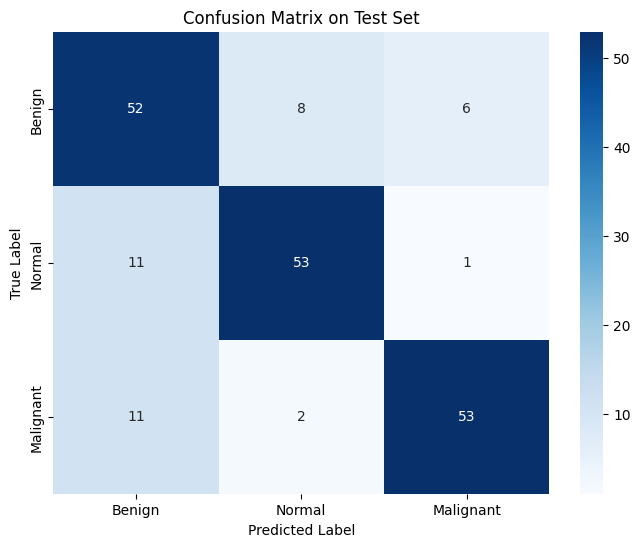

In [27]:
# Set up optimizer, scheduler, and loss function
optimizer = optim.Adam(model_effnet.classifier.parameters(), lr=0.001)
# NOTE: The 'verbose' argument is deprecated, it has been removed from this call.
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Initialize and run the trainer
trainer = Trainer(model_effnet, optimizer, criterion, scheduler=scheduler, device=device)
trainer.train(train_loader, val_loader, num_epochs=80)


#markdown ## **5. Model Evaluation and Visualization**
#markdown After training, we must evaluate the model's performance on the unseen test set and interpret its decisions.

#markdown ### **5.1. Performance Metrics on Test Set**

# Load the best model
model_effnet.load_state_dict(torch.load(trainer.best_model_path))
model_effnet.to(device)
model_effnet.eval()

# Get predictions
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model_effnet(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print("Classification Report on Test Set:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Normal', 'Malignant']))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Normal', 'Malignant'],
            yticklabels=['Benign', 'Normal', 'Malignant'])
plt.title('Confusion Matrix on Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [28]:
for name, module in model_effnet.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print(name, module)


features.0.0 Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
features.1.0.block.0.0 Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=64, bias=False)
features.1.0.block.1.fc1 Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1))
features.1.0.block.1.fc2 Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
features.1.0.block.2.0 Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
features.1.1.block.0.0 Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
features.1.1.block.1.fc1 Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
features.1.1.block.1.fc2 Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
features.1.1.block.2.0 Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
features.1.2.block.0.0 Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
features.1.2.block.1.fc1 Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
features.1.2.block.1.fc2 Conv2d(

Loading the saved model...
Model loaded successfully. Proceeding with Grad-CAM...


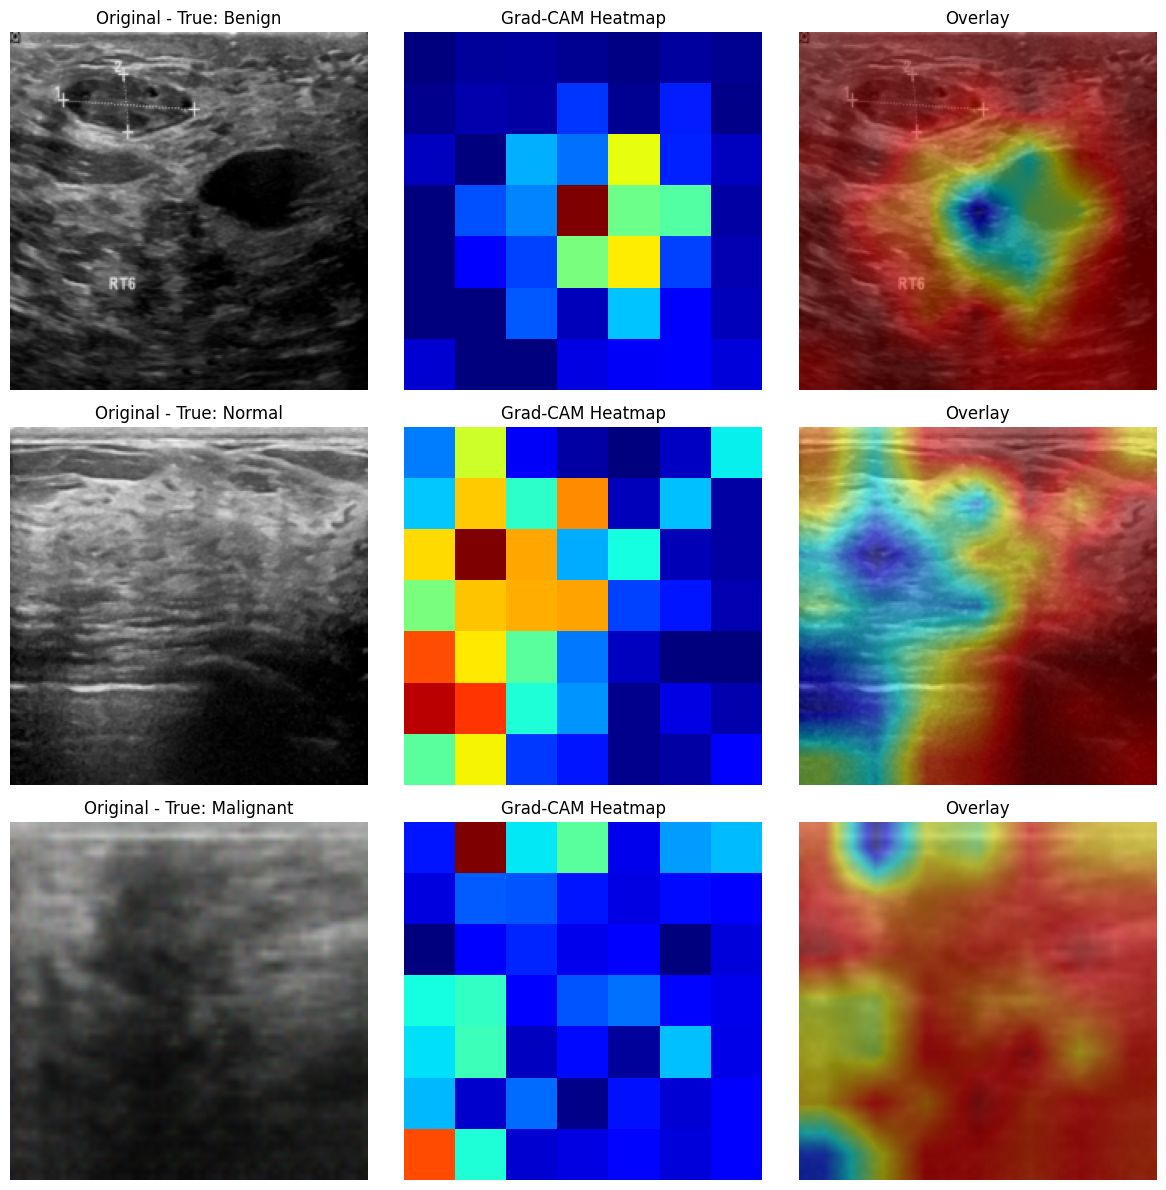

In [34]:
#@markdown ### **5.2. Model Explainability with Grad-CAM**
#@markdown **Grad-CAM** helps us understand *why* the model made a certain prediction by creating a heatmap of the important regions in the input image.

import torch
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

print("Loading the saved model...")

# 1. Re-create the model architecture
model_effnet = models.efficientnet_b7(pretrained=False)
num_ftrs = model_effnet.classifier[1].in_features
model_effnet.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 3)
)

# 2. Define the path to your saved model
saved_model_path = '/content/drive/MyDrive/model_for_plots.pth' # Fixed path

# 3. Load the saved weights into the model
model_effnet.load_state_dict(torch.load(saved_model_path, map_location=device))
model_effnet.to(device)
model_effnet.eval()

print("Model loaded successfully. Proceeding with Grad-CAM...")

# ---- GradCAM Function ----
def generate_gradcam(model, input_tensor, target_class, target_layer):
    # Dictionaries to store activations and gradients
    activations = {}
    gradients = {}

    # Hook functions
    def forward_hook(module, input, output):
        activations['value'] = output
        output.register_hook(backward_hook)

    def backward_hook(grad):
        gradients['value'] = grad

    # Register the forward hook to the target layer
    handle = target_layer.register_forward_hook(forward_hook)

    # Perform the forward pass
    output = model(input_tensor)
    if target_class is None:
        target_class = torch.argmax(output).item()

    score = output[:, target_class]

    # Perform the backward pass
    model.zero_grad()
    score.sum().backward()

    handle.remove()

    acts = activations['value'].cpu().data
    grads = gradients['value'].cpu().data

    pooled_grads = torch.mean(grads, dim=[0, 2, 3])

    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    heatmap = torch.mean(acts, dim=1).squeeze()
    heatmap = F.relu(heatmap)

    if torch.max(heatmap) > 0:
        heatmap /= torch.max(heatmap)

    return heatmap.numpy()

# --- THE FIX IS HERE ---
# The parameter name was changed from 'mask' to 'heatmap' to match its usage inside the function.
def show_gradcam_on_image(img, heatmap, alpha=0.5):
    """
    img: original numpy image (H, W, 3) scaled [0,1]
    heatmap: gradcam heatmap (H, W)
    """
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img_uint8 = np.uint8(img * 255)
    overlay = cv2.addWeighted(img_uint8, 1-alpha, heatmap, alpha, 0)
    return overlay


# ---- Grad-CAM visualization ----
fig, axs = plt.subplots(3, 3, figsize=(12, 12))
class_names = ['Benign', 'Normal', 'Malignant']

# Re-enable gradients for the model for Grad-CAM to work
for param in model_effnet.parameters():
    param.requires_grad = True

# Target the entire final feature block.
target_layer = model_effnet.features

for i in range(3):
    try:
        img_path = test_df[test_df['labels'] == i].iloc[0]['image_path']
        label = i

        image = Image.open(img_path).convert('RGB')
        input_tensor = val_test_transforms(image).unsqueeze(0).to(device)

        original_img_for_plot = np.transpose(input_tensor.squeeze(0).cpu().numpy(), (1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        original_img_for_plot = std * original_img_for_plot + mean
        original_img_for_plot = np.clip(original_img_for_plot, 0, 1)

        # Generate CAM
        heatmap = generate_gradcam(model_effnet, input_tensor,
                                 target_class=label,
                                 target_layer=target_layer)
        cam_img = show_gradcam_on_image(original_img_for_plot, heatmap)

        # Plot
        axs[i, 0].imshow(original_img_for_plot)
        axs[i, 0].set_title(f'Original - True: {class_names[i]}')
        axs[i, 0].axis('off')

        axs[i, 1].imshow(heatmap, cmap='jet')
        axs[i, 1].set_title('Grad-CAM Heatmap')
        axs[i, 1].axis('off')

        axs[i, 2].imshow(cam_img)
        axs[i, 2].set_title('Overlay')
        axs[i, 2].axis('off')

    except IndexError:
        print(f"No samples for class {class_names[i]} found in the test set to visualize.")
        for j in range(3):
            axs[i, j].axis("off")
        continue

plt.tight_layout()
plt.show()

In [37]:
#@title <h3><b>Live Inference and Grad-CAM Visualization</b></h3>
#@markdown Run this cell to upload an image and see the model's prediction.

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files

# --- 1. SETUP AND DEFINITIONS ---
class_names = ['Benign', 'Normal', 'Malignant']
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- 2. RE-CREATE THE MODEL ARCHITECTURE ---
model_to_load = models.efficientnet_b7(pretrained=False)
num_ftrs = model_to_load.classifier[1].in_features
model_to_load.classifier = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(512, 3)
)

# --- 3. LOAD THE TRAINED WEIGHTS ---
saved_model_path = '/content/drive/MyDrive/model_for_plots.pth' # Changed from best_model.pth
try:
    model_to_load.load_state_dict(torch.load(saved_model_path, map_location=device))
except FileNotFoundError:
    print(f"ERROR: Model file not found at {saved_model_path}")
    raise
model_to_load.to(device)
model_to_load.eval()
print("Model loaded successfully from Google Drive. Ready for inference!")

# --- 4. GRAD-CAM IMPLEMENTATION ---
# Note: This relies on the generate_gradcam and show_gradcam_on_image functions
# being defined in the cell above, as we confirmed was working.

# --- 5. IMAGE UPLOAD, PREDICTION, AND VISUALIZATION ---
uploaded = files.upload()

if len(uploaded.keys()) == 0:
    print("No file uploaded. Please run the cell again.")
else:
    file_name = next(iter(uploaded))
    print(f"\nProcessing '{file_name}'...")

    image = Image.open(file_name).convert('RGB')

    # Define transforms
    val_test_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    input_tensor = val_test_transforms(image).unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        output = model_to_load(input_tensor)
        probabilities = F.softmax(output, dim=1)
        confidence, pred_idx = torch.max(probabilities, 1)
        predicted_class = class_names[pred_idx.item()]

    # --- Grad-CAM ---

    # #############################################################################
    # IMPORTANT FIX: Unfreeze model layers for Grad-CAM
    # This loop allows gradients to be computed for the visualization.
    # It must be done before calling generate_gradcam.
    # #############################################################################
    for param in model_to_load.parameters():
        param.requires_grad = True

    target_layer = model_to_load.features
    heatmap = generate_gradcam(model_to_load, input_tensor,
                             target_class=pred_idx.item(),
                             target_layer=target_layer)

    # De-normalize original image for plotting
    original_img_for_plot = np.transpose(input_tensor.squeeze(0).cpu().numpy(), (1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    original_img_for_plot = std * original_img_for_plot + mean
    original_img_for_plot = np.clip(original_img_for_plot, 0, 1)

    cam_image = show_gradcam_on_image(original_img_for_plot, heatmap)

    # --- Display Results ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"Prediction: {predicted_class} ", fontsize=20)

    ax1.imshow(original_img_for_plot)
    ax1.set_title("Original Image")
    ax1.axis('off')

    ax2.imshow(heatmap, cmap='jet')
    ax2.set_title("Grad-CAM Heatmap")
    ax2.axis('off')

    ax3.imshow(cam_image)
    ax3.set_title("Heatmap Overlay")
    ax3.axis('off')

    plt.show()

Model loaded successfully from Google Drive. Ready for inference!


No file uploaded. Please run the cell again.


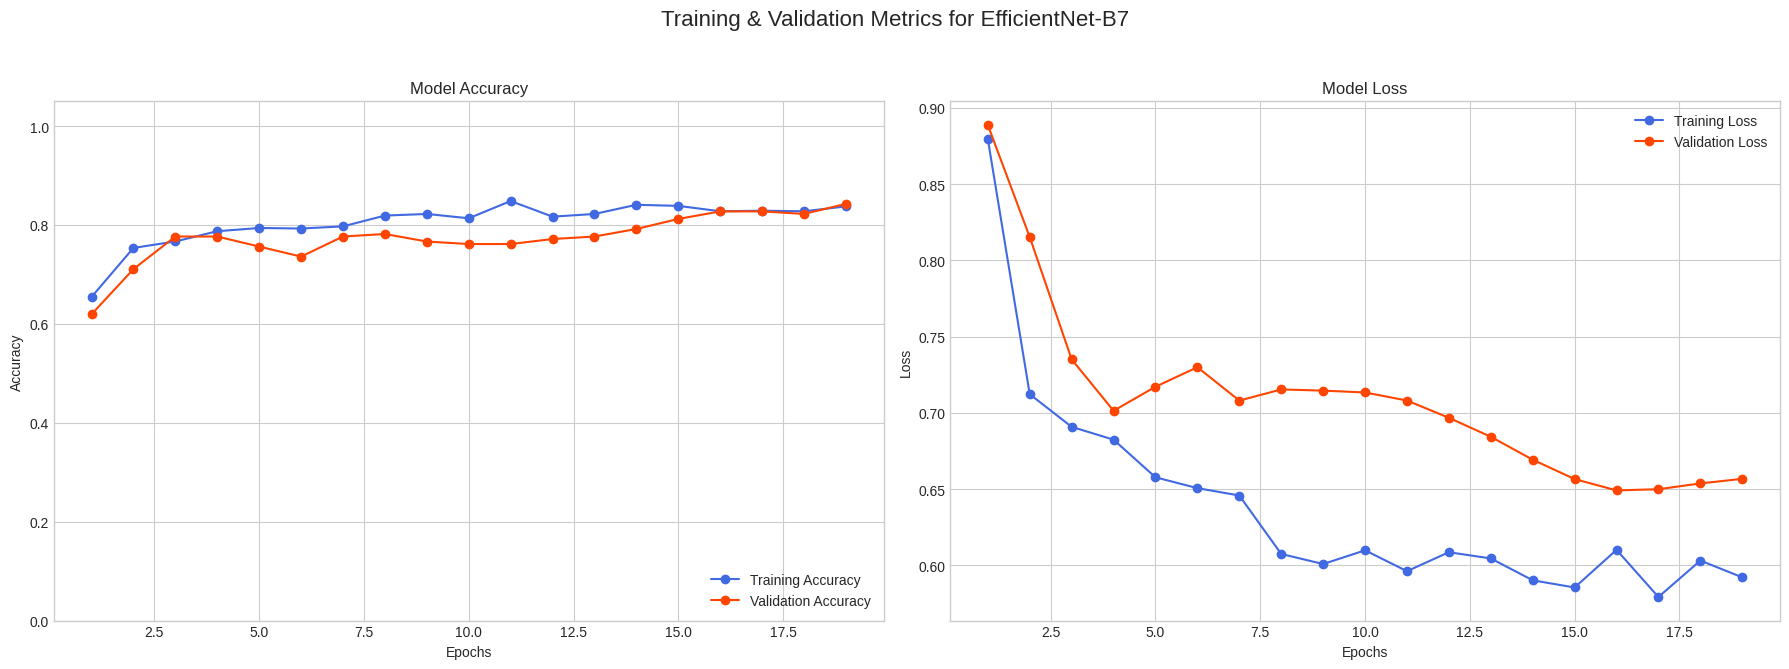

Model file not found at /content/drive/MyDrive/best_model.pth. Please ensure it is saved correctly.


In [39]:
"""
Breast Cancer Model Evaluation and Visualization Script

This script performs the following actions:
1. Loads a pre-trained PyTorch model (best_model.pth) from Google Drive.
2. Loads the training and validation metrics (training_metrics.json) from Google Drive.
3. Plots the Training vs. Validation Accuracy curve.
4. Plots the Training vs. Validation Loss curve.
5. Calculates and plots a detailed Confusion Matrix for the test set.
6. Calculates and plots the multi-class ROC curve and AUC scores for the test set.

Prerequisites (must be run in the same Colab session):
- Google Drive must be mounted.
- The following variables must be defined: `test_df`, `val_test_transforms`, `device`.
- The `CustomImageMaskDataset` class must be defined.
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelBinarizer
from PIL import Image

# --- Configuration and Constants ---
MODEL_PATH = '/content/drive/MyDrive/best_model.pth'
METRICS_PATH = '/content/drive/MyDrive/training_metrics.json'
CLASS_NAMES = ['Benign', 'Normal', 'Malignant']
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- Plotting Functions ---

def plot_training_results(metrics, model_name):
    """Plots the training & validation accuracy and loss curves."""
    epochs = range(1, len(metrics.get('train_loss', [])) + 1)

    if not epochs:
        print("Metrics dictionary is empty. Cannot plot training results.")
        return

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f'Training & Validation Metrics for {model_name}', fontsize=16)

    # Plot Accuracy
    ax1.plot(epochs, metrics['train_accuracy'], 'o-', color='royalblue', label='Training Accuracy')
    ax1.plot(epochs, metrics['val_accuracy'], 'o-', color='orangered', label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right')
    ax1.set_ylim(bottom=0, top=1.05)

    # Plot Loss
    ax2.plot(epochs, metrics['train_loss'], 'o-', color='royalblue', label='Training Loss')
    ax2.plot(epochs, metrics['val_loss'], 'o-', color='orangered', label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names):
    """Calculates and plots a confusion matrix."""
    print("\n" + "="*50)
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print("="*50 + "\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14})
    plt.title('Confusion Matrix on Test Set', fontsize=16)
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

# --- NEW FUNCTION: PLOT ROC CURVE ---
def plot_roc_curve(y_true, y_score, class_names):
    """Calculates and plots the multi-class ROC curve and AUC scores."""
    # Binarize the labels for the One-vs-Rest ROC curve
    lb = LabelBinarizer()
    y_true_bin = lb.fit_transform(y_true)
    n_classes = y_true_bin.shape[1]

    # Dictionaries to hold ROC curve data
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    # Calculate ROC curve and AUC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = ['aqua', 'darkorange', 'cornflowerblue']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC curve of class {0} (area = {1:0.2f})'
                 ''.format(class_names[i], roc_auc[i]))

    # Plot the "random guess" line
    plt.plot([0, 1], [0, 1], 'k--', lw=2)

    # Set plot labels and title
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Multi-Class Receiver Operating Characteristic (ROC) Curve', fontsize=16)
    plt.legend(loc="lower right")
    plt.show()

# --- Main Execution ---

# 1. Load and Plot Training History
try:
    with open(METRICS_PATH, 'r') as f:
        training_metrics = json.load(f)
    plot_training_results(training_metrics, "EfficientNet-B7")
except FileNotFoundError:
    print(f"Metrics file not found at {METRICS_PATH}. Please re-run the training notebook to save it.")
except json.JSONDecodeError:
    print(f"Error reading the metrics file. It might be empty or corrupted.")

# 2. Load Model and Evaluate on Test Set
try:
    # Re-create the model architecture
    model_effnet = models.efficientnet_b7(pretrained=False)
    num_ftrs = model_effnet.classifier[1].in_features
    model_effnet.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, 3)
    )

    # Load the saved weights
    model_effnet.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model_effnet.to(DEVICE)
    model_effnet.eval()
    print("\n✅ Best model loaded successfully from Google Drive.")

    # Prepare the test dataloader
    test_dataset = CustomImageMaskDataset(test_df, val_test_transforms)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # --- UPDATED: Get predictions AND raw scores (probabilities) ---
    all_preds = []
    all_labels = []
    all_scores = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model_effnet(inputs)

            # Get raw scores and apply softmax
            scores = F.softmax(outputs, dim=1)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(scores.cpu().numpy())

    # Convert scores to a numpy array for scikit-learn
    all_scores = np.array(all_scores)

    # Plot the confusion matrix
    plot_confusion_matrix(all_labels, all_preds, CLASS_NAMES)

    # --- ADDED: Plot the ROC curve ---
    plot_roc_curve(all_labels, all_scores, CLASS_NAMES)

except FileNotFoundError:
    print(f"Model file not found at {MODEL_PATH}. Please ensure it is saved correctly.")
except NameError as e:
    print(f"Error: {e}. Please ensure you have run the initial setup cells to define variables like 'test_df', 'device', 'val_test_transforms', and the 'CustomImageMaskDataset' class.")

✅ Metrics loaded successfully from /content/drive/MyDrive/training_metrics.json


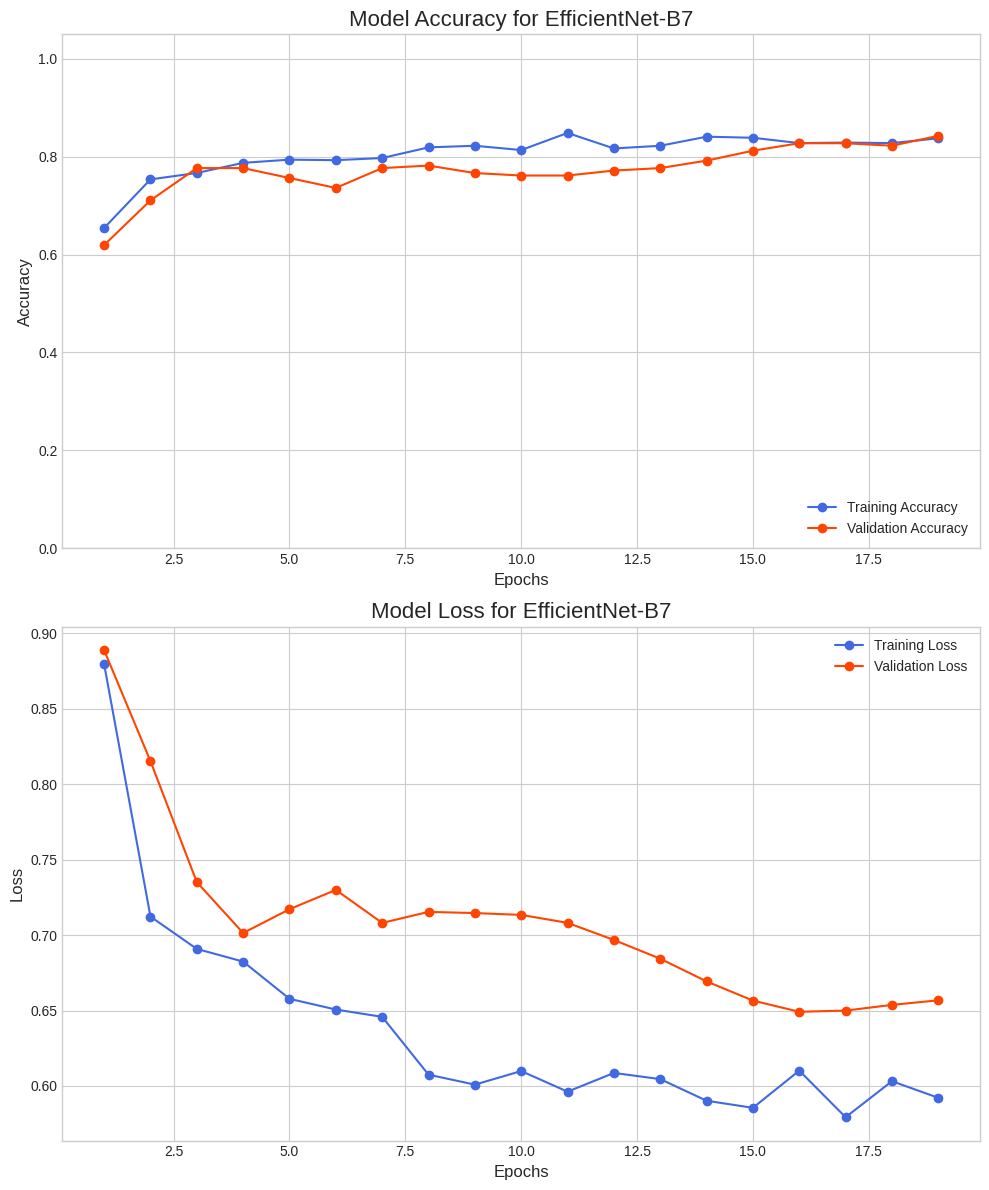

In [40]:
import matplotlib.pyplot as plt
import json

# --- Configuration ---
METRICS_PATH = '/content/drive/MyDrive/training_metrics.json'
MODEL_NAME = "EfficientNet-B7"

# --- Load the saved metrics data ---
try:
    with open(METRICS_PATH, 'r') as f:
        metrics = json.load(f)
    print(f"✅ Metrics loaded successfully from {METRICS_PATH}")

    epochs = range(1, len(metrics.get('train_loss', [])) + 1)

    if not epochs:
        print("Metrics dictionary is empty. Cannot plot results.")
    else:
        plt.style.use('seaborn-v0_8-whitegrid')

        # --- Create subplots (2 rows, 1 column) ---
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

        # --- Plot 1: Model Accuracy ---
        ax1.plot(epochs, metrics['train_accuracy'], 'o-', color='royalblue', label='Training Accuracy')
        ax1.plot(epochs, metrics['val_accuracy'], 'o-', color='orangered', label='Validation Accuracy')
        ax1.set_title(f'Model Accuracy for {MODEL_NAME}', fontsize=16)
        ax1.set_xlabel('Epochs', fontsize=12)
        ax1.set_ylabel('Accuracy', fontsize=12)
        ax1.legend(loc='lower right')
        ax1.set_ylim(bottom=0, top=1.05)

        # --- Plot 2: Model Loss ---
        ax2.plot(epochs, metrics['train_loss'], 'o-', color='royalblue', label='Training Loss')
        ax2.plot(epochs, metrics['val_loss'], 'o-', color='orangered', label='Validation Loss')
        ax2.set_title(f'Model Loss for {MODEL_NAME}', fontsize=16)
        ax2.set_xlabel('Epochs', fontsize=12)
        ax2.set_ylabel('Loss', fontsize=12)
        ax2.legend(loc='upper right')

        # --- Adjust layout ---
        plt.tight_layout()
        plt.show()

except FileNotFoundError:
    print(f"ERROR: Metrics file not found at {METRICS_PATH}. Please ensure you have run the training cell to generate this file.")
except Exception as e:
    print(f"An error occurred: {e}")


In [41]:
import torch
import torch.nn as nn
from torchvision import models, transforms
import numpy as np
import json
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import resample
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# --- 1. Load Model and Get Predictions ---

MODEL_PATH = '/content/drive/MyDrive/best_model.pth'
CLASS_NAMES = ['Benign', 'Normal', 'Malignant']
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

try:
    # Re-create the model architecture
    model_effnet = models.efficientnet_b7(pretrained=False)
    num_ftrs = model_effnet.classifier[1].in_features
    model_effnet.classifier = nn.Sequential(
        nn.Linear(num_ftrs, 512), nn.ReLU(), nn.Dropout(0.5), nn.Linear(512, 3)
    )

    # Load the saved weights
    model_effnet.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
    model_effnet.to(DEVICE)
    model_effnet.eval()
    print("✅ Best model loaded successfully from Google Drive.")

    # Prepare the test dataloader (assumes `test_df` and `val_test_transforms` are defined)
    test_dataset = CustomImageMaskDataset(test_df, val_test_transforms)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

    # Get predictions
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(DEVICE)
            outputs = model_effnet(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    print("✅ Test set predictions generated.")

    # --- 2. Run Bootstrap Analysis ---
    print("\nCalculating 95% Confidence Intervals (1,000 iterations)...")

    n_iterations = 1000
    n_size = len(all_labels)

    bootstrapped_accuracies = []
    bootstrapped_f1_per_class = {name: [] for name in CLASS_NAMES}

    for i in range(n_iterations):
        # Create a resampled set
        indices = resample(range(n_size), replace=True, n_samples=n_size)
        boot_labels = [all_labels[idx] for idx in indices]
        boot_preds = [all_preds[idx] for idx in indices]

        # Calculate metrics
        bootstrapped_accuracies.append(accuracy_score(boot_labels, boot_preds))

        f1_per_class = f1_score(boot_labels, boot_preds, average=None, labels=[0, 1, 2], zero_division=0)
        for j, name in enumerate(CLASS_NAMES):
            bootstrapped_f1_per_class[name].append(f1_per_class[j])

    # --- 3. Display Results ---
    alpha = 0.95
    lower_p = ((1.0 - alpha) / 2.0) * 100
    upper_p = (alpha + ((1.0 - alpha) / 2.0)) * 100

    # Overall Accuracy CI
    accuracy_ci = (
        np.percentile(bootstrapped_accuracies, lower_p),
        np.percentile(bootstrapped_accuracies, upper_p)
    )

    # Per-Class F1-Score CIs
    f1_per_class_ci = {}
    for name in CLASS_NAMES:
        f1_per_class_ci[name] = (
            np.percentile(bootstrapped_f1_per_class[name], lower_p),
            np.percentile(bootstrapped_f1_per_class[name], upper_p)
        )

    print("\n" + "="*50)
    print("--- 95% CONFIDENCE INTERVAL RESULTS ---")
    print("Copy these values into your LaTeX paper:")
    print("="*50)

    original_acc = accuracy_score(all_labels, all_preds)
    print(f"\nOverall Accuracy: {original_acc*100:.1f}% (95% CI: [{accuracy_ci[0]*100:.1f}% - {accuracy_ci[1]*100:.1f}%])")

    print("\nPer-Class F1-Scores (95% CI):")
    f1_original_per_class = f1_score(all_labels, all_preds, average=None, labels=[0, 1, 2])
    for i, name in enumerate(CLASS_NAMES):
        print(f"  - {name}: {f1_original_per_class[i]:.2f} (95% CI: [{f1_per_class_ci[name][0]:.2f} - {f1_per_class_ci[name][1]:.2f}])")

    print("\n" + "="*50)

except NameError as e:
    print(f"\nERROR: A variable was not defined. {e}")
    print("Please ensure you have run the initial setup cells from your notebook to define:")
    print("1. `CustomImageMaskDataset` class")
    print("2. `test_df`")
    print("3. `val_test_transforms`")
except FileNotFoundError:
    print(f"\nERROR: Model file not found at {MODEL_PATH}.")
    print("Please ensure 'best_model.pth' is in your Google Drive.")


ERROR: Model file not found at /content/drive/MyDrive/best_model.pth.
Please ensure 'best_model.pth' is in your Google Drive.
